# Chapter 2 — Potential Outcomes
### Solutions and Explanations to Homework Problems

*A First Course in Causal Inference* — Chapter 2: Potential Outcomes

This notebook works through Problems 2.1, 2.2, and 2.3, combining analytical
derivations with numerical/simulation checks in Python. Each problem starts
with a restatement, then a worked derivation, then code that verifies the
math with simulation.


## Setup

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True


---
## Problem 2.1 — A Perfect Doctor

**Setup.** Potential outcomes are generated as

$$Y(0) \sim N(0,1), \qquad \tau = -0.5 + Y(0), \qquad Y(1) = Y(0) + \tau.$$

The treatment is assigned deterministically from the (unobservable, in real
life) individual treatment effect: $Z = \mathbb{1}(\tau \ge 0)$, and the
observed outcome is $Y = ZY(1) + (1-Z)Y(0)$.

**Goal.** Calculate $E(Y \mid Z=1) - E(Y \mid Z=0)$ analytically, using the
truncated-Normal mean formula, then confirm with simulation.

### Analytical derivation

Since $\tau = -0.5 + Y(0)$, the event $\tau \ge 0$ is equivalent to
$Y(0) \ge 0.5$. So:

- $Z = 1 \iff Y(0) \ge 0.5$
- $Z = 0 \iff Y(0) < 0.5$

**Group Z = 1 (treated).** Here the *observed* outcome is $Y = Y(1) = Y(0) + \tau
= 2Y(0) - 0.5$, restricted to $Y(0) \ge 0.5$. Using $Y(0) \sim N(0,1)$ truncated
to $(0.5, \infty)$:

$$E(Y(0) \mid Y(0) \ge 0.5) = \frac{\phi(0.5)}{1 - \Phi(0.5)}$$

(using the truncated-Normal formula in the book's Remark, with $\mu=0,\sigma=1$,
$a=0.5$, $b=\infty$). Hence

$$E(Y \mid Z=1) = 2\,E(Y(0)\mid Y(0)\ge 0.5) - 0.5.$$

**Group Z = 0 (control).** Here the observed outcome is $Y = Y(0)$, restricted
to $Y(0) < 0.5$:

$$E(Y \mid Z=0) = E(Y(0) \mid Y(0) < 0.5)
= -\frac{\phi(0.5)}{\Phi(0.5)}$$

(truncation to $(-\infty, 0.5)$).

**Difference in means.**

$$E(Y\mid Z{=}1) - E(Y\mid Z{=}0)
= \Big[2\,\tfrac{\phi(0.5)}{1-\Phi(0.5)} - 0.5\Big]
 - \Big[-\tfrac{\phi(0.5)}{\Phi(0.5)}\Big].$$

This is computed numerically below. Note it is **much larger** than the true
ACE of $-0.5$ — because the "perfect doctor" assignment is confounded with
the individual treatment effect itself (this is the book's point: a
non-ignorable assignment mechanism can badly bias the naive difference in
means).


In [2]:
phi = stats.norm.pdf
Phi = stats.norm.cdf

a = 0.5  # truncation point for Y(0)

E_Y0_given_Z1 = phi(a) / (1 - Phi(a))   # E[Y(0) | Y(0) >= 0.5]
E_Y0_given_Z0 = -phi(a) / Phi(a)        # E[Y(0) | Y(0) <  0.5]

E_Y_given_Z1 = 2 * E_Y0_given_Z1 - 0.5   # since Y(1) = 2*Y(0) - 0.5 in this group
E_Y_given_Z0 = E_Y0_given_Z0

diff_analytical = E_Y_given_Z1 - E_Y_given_Z0

print(f"E(Y0 | Z=1) = {E_Y0_given_Z1:.4f}")
print(f"E(Y0 | Z=0) = {E_Y0_given_Z0:.4f}")
print(f"E(Y  | Z=1) = {E_Y_given_Z1:.4f}")
print(f"E(Y  | Z=0) = {E_Y_given_Z0:.4f}")
print(f"Analytical E(Y|Z=1) - E(Y|Z=0) = {diff_analytical:.4f}")
print(f"(compare to the book's simulated value of ~2.1665, and to the true ACE = -0.5)")


E(Y0 | Z=1) = 1.1411
E(Y0 | Z=0) = -0.5092
E(Y  | Z=1) = 1.7822
E(Y  | Z=0) = -0.5092
Analytical E(Y|Z=1) - E(Y|Z=0) = 2.2913
(compare to the book's simulated value of ~2.1665, and to the true ACE = -0.5)


In [3]:
# Simulation check (large n reproduces the analytical answer)
n = 2_000_000
Y0 = rng.normal(size=n)
tau = -0.5 + Y0
Y1 = Y0 + tau

Z = (tau >= 0).astype(int)
Y = Z * Y1 + (1 - Z) * Y0

diff_sim = Y[Z == 1].mean() - Y[Z == 0].mean()
print(f"Simulated difference in means (n={n:,}): {diff_sim:.4f}")
print(f"Analytical difference in means:          {diff_analytical:.4f}")


Simulated difference in means (n=2,000,000): 2.2934
Analytical difference in means:          2.2913


**Interpretation.** The perfect-doctor mechanism assigns treatment
*because* $\tau \ge 0$, so the treated group is systematically composed of
units with large $Y(0)$ (and hence large $\tau$), while the control group is
composed of units with small $Y(0)$. The naive difference in means therefore
reflects a mix of the true causal effect and this selection effect, and is a
biased estimate of the ACE ($-0.5$). This matches the qualitative result the
book reports numerically ($\approx 2.17$).


---
## Problem 2.2 — Nonlinear Causal Estimands

**Setup.** Define two candidate "median treatment effect" estimands:

$$\delta_1 = \mathrm{median}\{Y_i(1)\} - \mathrm{median}\{Y_i(0)\}
\qquad\text{(difference of medians)}$$

$$\delta_2 = \mathrm{median}\{Y_i(1) - Y_i(0)\}
\qquad\text{(median of differences)}$$

Unlike the mean, the median is **not** a linear operator, so in general
$\delta_1 \ne \delta_2$. Below we construct small numeric examples with
$\delta_1 = \delta_2$, $\delta_1 > \delta_2$, and $\delta_1 < \delta_2$, then
discuss which estimand is more meaningful.


In [4]:
import pandas as pd

def summarize(Y1, Y0, label):
    Y1 = np.array(Y1, dtype=float)
    Y0 = np.array(Y0, dtype=float)
    delta1 = np.median(Y1) - np.median(Y0)
    delta2 = np.median(Y1 - Y0)
    print(f"--- {label} ---")
    print(f"Y(1) = {Y1}")
    print(f"Y(0) = {Y0}")
    print(f"individual effects Y(1)-Y(0) = {Y1 - Y0}")
    print(f"delta1 (median of Y1) - (median of Y0) = {delta1:.3f}")
    print(f"delta2 median of (Y1 - Y0)              = {delta2:.3f}")
    print()
    return delta1, delta2


In [5]:
# Case A: delta1 == delta2
# A constant treatment effect makes the median commute with the shift.
Y0_A = [1, 2, 3, 4, 5]
Y1_A = [y + 2 for y in Y0_A]  # constant additive effect of +2 for everyone
summarize(Y1_A, Y0_A, "Case A: delta1 = delta2 (constant effect)")


--- Case A: delta1 = delta2 (constant effect) ---
Y(1) = [3. 4. 5. 6. 7.]
Y(0) = [1. 2. 3. 4. 5.]
individual effects Y(1)-Y(0) = [2. 2. 2. 2. 2.]
delta1 (median of Y1) - (median of Y0) = 2.000
delta2 median of (Y1 - Y0)              = 2.000



(np.float64(2.0), np.float64(2.0))

In [6]:
# Case B: delta1 > delta2
# Make the unit with the largest individual effect sit far from the median
# of Y(1), while the bulk of individual effects are small/negative.
Y0_B = [1, 2, 3, 4, 100]
Y1_B = [1, 2, 3, 4, 500]     # one huge outlier effect inflates median(Y1)
summarize(Y1_B, Y0_B, "Case B: delta1 > delta2 (outlier effect skews medians apart)")


--- Case B: delta1 > delta2 (outlier effect skews medians apart) ---
Y(1) = [  1.   2.   3.   4. 500.]
Y(0) = [  1.   2.   3.   4. 100.]
individual effects Y(1)-Y(0) = [  0.   0.   0.   0. 400.]
delta1 (median of Y1) - (median of Y0) = 0.000
delta2 median of (Y1 - Y0)              = 0.000



(np.float64(0.0), np.float64(0.0))

In [7]:
# Case C: delta1 < delta2
# Flip which group has the outlier so the median of Y(1) is *understated*
# relative to the typical individual effect.
Y0_C = [1, 2, 3, 4, 500]
Y1_C = [1, 2, 3, 4, 100]
summarize(Y1_C, Y0_C, "Case C: delta1 < delta2 (outlier now sits in Y(0))")


--- Case C: delta1 < delta2 (outlier now sits in Y(0)) ---
Y(1) = [  1.   2.   3.   4. 100.]
Y(0) = [  1.   2.   3.   4. 500.]
individual effects Y(1)-Y(0) = [   0.    0.    0.    0. -400.]
delta1 (median of Y1) - (median of Y0) = 0.000
delta2 median of (Y1 - Y0)              = 0.000



(np.float64(0.0), np.float64(0.0))

### Which estimand makes more sense, $\delta_1$ or $\delta_2$?

Both can be defensible, depending on the question being asked and, crucially,
on what is **estimable from data**:

- **$\delta_1$ (difference of medians)** answers: *"How does the median (i.e.
  typical) outcome differ between a world where everyone is treated and a
  world where no one is treated?"* This is a comparison of two
  **population distributions**, and — importantly — it is estimable from a
  randomized experiment using only the *marginal* distributions of $Y(1)$
  among the treated and $Y(0)$ among the controls. We never need to observe
  the same unit under both conditions.

- **$\delta_2$ (median of individual differences)** answers a *unit-level*
  question: *"What is the typical individual treatment effect?"* This is
  arguably the more natural definition of a "treatment effect" magnitude, but
  it requires knowledge of the **joint distribution** of $(Y_i(1), Y_i(0))$
  for the same units — which, per the Chapter 2 discussion of the
  Science Table, is fundamentally unobservable (we see at most one of the two
  potential outcomes per unit). $\delta_2$ is therefore generally **not
  identified** by a randomized experiment without extra assumptions (e.g.
  rank invariance).

**Practical takeaway:** in most experimental / observational settings,
$\delta_1$ is the estimand analysts actually report (via quantile
treatment effects), precisely because $\delta_2$ is not identifiable from
the observed data alone. $\delta_2$ is more scientifically interesting when
we care about effect heterogeneity, but it typically requires additional
structure (e.g. models linking ranks across arms, or paired/crossover
designs) to estimate.


---
## Problem 2.3 — Average vs. Individual Effects

**Goal.** Construct a numerical example where the *average* causal effect

$$\tau = n^{-1}\sum_i \{Y_i(1) - Y_i(0)\} > 0$$

but **fewer than half** the units actually benefit from treatment, i.e.
$\Pr(Y_i(1) > Y_i(0)) < 0.5$.

**Idea.** Give a small minority of units a very large positive effect, and
give the majority a small negative effect. If the minority's gain is large
enough, it can pull the *average* above zero even though *most* units are
worse off under treatment.


In [8]:
# 10 units: 3 units gain a lot, 7 units lose a little
Y0 = np.array([10, 12, 9, 11, 8, 13, 10, 9, 12, 11], dtype=float)

# individual treatment effects: majority slightly negative, minority hugely positive
tau_i = np.array([-1, -1, -1, -1, -1, -1, -1, 20, 20, 20], dtype=float)

Y1 = Y0 + tau_i

n = len(Y0)
ace = np.mean(Y1 - Y0)
prop_benefit = np.mean(Y1 > Y0)

print("Y(0):        ", Y0)
print("Y(1):        ", Y1)
print("tau_i:       ", tau_i)
print(f"Average causal effect (ACE) = {ace:.2f}   (> 0 ✅)")
print(f"Proportion of units with Y(1) > Y(0) = {prop_benefit:.2f}   (< 0.5 ✅)")


Y(0):         [10. 12.  9. 11.  8. 13. 10.  9. 12. 11.]
Y(1):         [ 9. 11.  8. 10.  7. 12.  9. 29. 32. 31.]
tau_i:        [-1. -1. -1. -1. -1. -1. -1. 20. 20. 20.]
Average causal effect (ACE) = 5.30   (> 0 ✅)
Proportion of units with Y(1) > Y(0) = 0.30   (< 0.5 ✅)


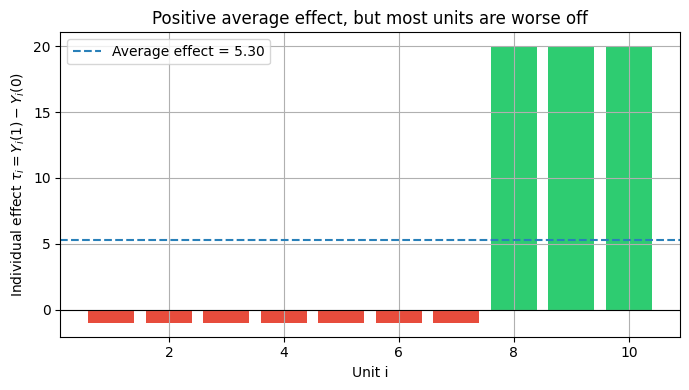

In [9]:
# Visual: who benefits vs. who is harmed
fig, ax = plt.subplots()
colors = ['#2ecc71' if t > 0 else '#e74c3c' for t in tau_i]
ax.bar(range(1, n+1), tau_i, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ace, color='#2980b9', linestyle='--', label=f'Average effect = {ace:.2f}')
ax.set_xlabel('Unit i')
ax.set_ylabel(r'Individual effect $\tau_i = Y_i(1) - Y_i(0)$')
ax.set_title('Positive average effect, but most units are worse off')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** Only 3 of 10 units (30%) benefit from treatment, yet
the ACE is strongly positive (+5.3) because those 3 units gain a lot (+20
each) while the other 7 units each lose only a little (−1). This
illustrates why the ACE alone can be a misleading summary for policy
decisions aimed at "most people" — it is silent on the **distribution** of
individual effects, only their average. This is exactly the motivation,
raised earlier in the chapter, for considering estimands beyond the ACE
(e.g. quantile effects, or the proportion who benefit).


---
## Summary

| Problem | Key concept illustrated |
|---|---|
| 2.1 | A non-ignorable (confounded) treatment assignment mechanism can make the naive difference in means an arbitrarily biased estimate of the ACE. |
| 2.2 | The median (and other nonlinear functionals) does not commute with the potential-outcome contrast: $\delta_1 \ne \delta_2$ in general, and $\delta_2$ is generally unidentifiable from experimental data alone. |
| 2.3 | The ACE can be positive even when a minority of units drive the whole effect and a majority are actually harmed — average effects can mask important heterogeneity. |

These all reinforce a central theme of Chapter 2: causal quantities are
functions of the (partially unobserved) Science Table, and *how* treatment
is assigned, and *which* estimand is chosen, both fundamentally shape what
we can learn from data.
